# Detailed Evaluation

In [1]:
# Libraries
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
project_root = (
    Path.cwd().parent
    if Path.cwd().name == 'notebooks'
    else Path.cwd()
)

predictions_path = (
    project_root
    / 'data'
    / 'processed'
    / 'ca1_final_test_predictions.parquet'
)

features_path = (
    project_root
    / 'data'
    / 'processed'
    / 'ca1_model_features.parquet'
)

reports_directory = (
    project_root
    / 'reports'
)

figures_directory = (
    reports_directory
    / 'figures'
)

reports_directory.mkdir(
    parents=True,
    exist_ok=True
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# Loading results from previous notebook
test_predictions = pd.read_parquet(
    predictions_path
)

feature_df = pd.read_parquet(
    features_path
)

test_predictions['date'] = pd.to_datetime(
    test_predictions['date']
)

feature_df['date'] = pd.to_datetime(
    feature_df['date']
)

print(
    f'Prediction rows: '
    f'{len(test_predictions):,}'
)

print(
    f'Models: '
    f'{test_predictions["model"].nunique()}'
)

print(
    f'Items: '
    f'{test_predictions["item_id"].nunique()}'
)

print(
    f'Test dates: '
    f'{test_predictions["date"].nunique()}'
)

Prediction rows: 21,168
Models: 7
Items: 108
Test dates: 28


In [4]:
# Checking missingness
print(
    'Missing forecasts:',
    test_predictions[
        'forecast'
    ].isna().sum()
)

print(
    'Negative final forecasts:',
    test_predictions[
        'forecast'
    ].lt(0).sum()
)

print(
    'Duplicate model-item-date rows:',
    test_predictions.duplicated(
        subset=[
            'model',
            'item_id',
            'date'
        ]
    ).sum()
)

Missing forecasts: 0
Negative final forecasts: 0
Duplicate model-item-date rows: 0


### Metrics function (grouping)

In [5]:
def calculate_grouped_metrics(
    data,
    group_columns
):
    metric_rows = []

    for group_values, group in data.groupby(
        group_columns,
        observed=True,
        dropna=False
    ):
        if not isinstance(
            group_values,
            tuple
        ):
            group_values = (
                group_values,
            )

        actual = group[
            'sales'
        ].to_numpy(dtype=float)

        forecast = group[
            'forecast'
        ].to_numpy(dtype=float)

        error = (
            forecast
            - actual
        )

        denominator = np.abs(
            actual
        ).sum()

        metrics = {
            column: value
            for column, value in zip(
                group_columns,
                group_values
            )
        }

        metrics.update({
            'observations': len(group),
            'total_actual_sales':
                actual.sum(),
            'total_forecast_sales':
                forecast.sum(),
            'MAE':
                np.abs(error).mean(),
            'RMSE':
                np.sqrt(
                    np.mean(error ** 2)
                ),
            'WAPE': (
                np.abs(error).sum()
                / denominator
                if denominator > 0
                else np.nan
            ),
            'bias':
                error.mean()
        })

        metric_rows.append(metrics)

    return pd.DataFrame(
        metric_rows
    )

In [6]:
# Overall comparison
overall_metrics = (
    calculate_grouped_metrics(
        test_predictions,
        ['model']
    )
    .sort_values(
        ['WAPE', 'RMSE']
    )
    .reset_index(drop=True)
)

overall_metrics[
    'WAPE_percentage'
] = (
    overall_metrics['WAPE']
    * 100
)

overall_metrics

,model,observations,total_actual_sales,total_forecast_sales,MAE,RMSE,WAPE,bias,WAPE_percentage
0,random_forest_tuned,3024,5035.0,4633.009676,1.273318,2.666395,0.764750,-0.132933,76.474972
1,rolling_mean_28,3024,5035.0,4573.744584,1.275715,2.712615,0.766189,-0.152532,76.618906
2,xgboost_tuned,3024,5035.0,4865.552676,1.312323,2.677344,0.788176,-0.056034,78.817553
3,linear_regression,3024,5035.0,5672.014075,1.356158,2.734692,0.814503,0.210653,81.450270
4,ridge_regression,3024,5035.0,5692.224698,1.360844,2.734023,0.817317,0.217336,81.731737
5,seasonal_naive_7,3024,5035.0,4276.000000,1.449405,3.314580,0.870506,-0.250992,87.050645
6,previous_day,3024,5035.0,5852.000000,1.596892,3.242258,0.959086,0.270172,95.908640


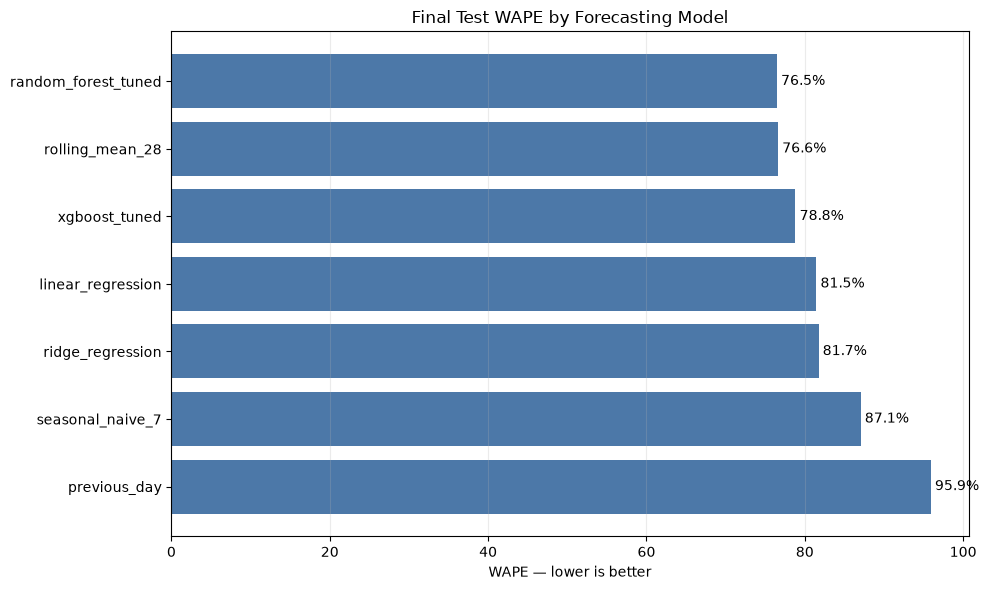

In [7]:
# Overal WAPE results
plot_data = (
    overall_metrics
    .sort_values(
        'WAPE_percentage',
        ascending=False
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    plot_data['model'],
    plot_data['WAPE_percentage'],
    color='#4C78A8'
)

ax.bar_label(
    bars,
    fmt='%.1f%%',
    padding=3
)

ax.set_title(
    'Final Test WAPE by Forecasting Model'
)

ax.set_xlabel(
    'WAPE — lower is better'
)

ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'final_test_model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Performance by category

In [8]:
category_metrics = (
    calculate_grouped_metrics(
        test_predictions,
        [
            'model',
            'cat_id'
        ]
    )
    .sort_values(
        [
            'cat_id',
            'WAPE'
        ]
    )
)

category_metrics[
    'WAPE_percentage'
] = (
    category_metrics['WAPE']
    * 100
)

category_metrics[
    [
        'cat_id',
        'model',
        'MAE',
        'RMSE',
        'WAPE_percentage',
        'bias'
    ]
]

,cat_id,model,MAE,RMSE,WAPE_percentage,bias
6,FOODS,random_forest_tuned,1.702469,2.962790,61.420492,-0.285580
18,FOODS,xgboost_tuned,1.722848,2.968371,62.155715,-0.221023
12,FOODS,rolling_mean_28,1.750006,2.999628,63.135510,-0.169488
0,FOODS,linear_regression,1.787597,3.106203,64.491701,0.276515
9,FOODS,ridge_regression,1.798237,3.102519,64.875548,0.294518
15,FOODS,seasonal_naive_7,1.900794,3.472683,68.575519,-0.323413
3,FOODS,previous_day,2.186508,3.635692,78.883321,0.700397
13,HOBBIES,rolling_mean_28,1.339371,3.417077,91.221993,-0.298514
7,HOBBIES,random_forest_tuned,1.393573,3.349081,94.913632,-0.078863
19,HOBBIES,xgboost_tuned,1.459274,3.374356,99.388382,0.030680


In [9]:
# Comparison table
category_wape_table = (
    category_metrics.pivot(
        index='model',
        columns='cat_id',
        values='WAPE_percentage'
    )
)

category_wape_table

cat_id,FOODS,HOBBIES,HOUSEHOLD
model,,,
linear_regression,64.491701,101.375810,104.962021
previous_day,78.883321,122.027027,107.621551
random_forest_tuned,61.420492,94.913632,95.887589
ridge_regression,64.875548,101.323966,105.515829
rolling_mean_28,63.135510,91.221993,97.722767
seasonal_naive_7,68.575519,113.648649,103.153745
xgboost_tuned,62.155715,99.388382,99.984895


### Plotting RF against the strongest baseline

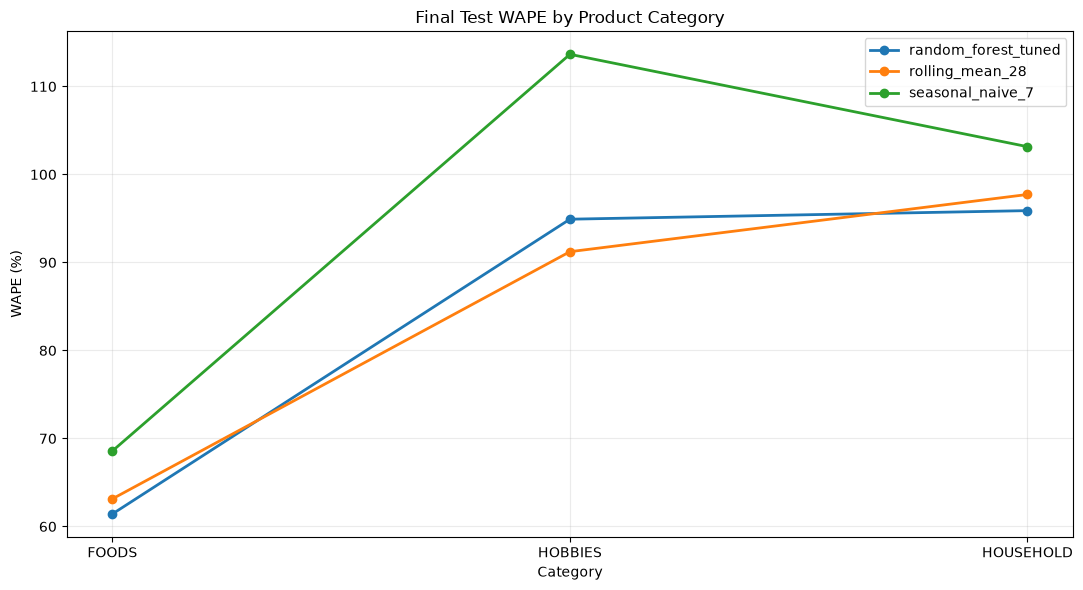

In [11]:
category_plot_data = (
    category_metrics.loc[
        category_metrics[
            'model'
        ].isin([
            'random_forest_tuned',
            'rolling_mean_28',
            'seasonal_naive_7'
        ])
    ]
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for model_name, group in (
    category_plot_data.groupby('model')
):
    group = group.sort_values(
        'cat_id'
    )

    ax.plot(
        group['cat_id'],
        group['WAPE_percentage'],
        marker='o',
        linewidth=2,
        label=model_name
    )

ax.set_title(
    'Final Test WAPE by Product Category'
)

ax.set_xlabel(
    'Category'
)

ax.set_ylabel(
    'WAPE (%)'
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'category_performance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [12]:
# Demand intermittemcy groups
test_start = (
    test_predictions[
        'date'
    ].min()
)

development_history = feature_df.loc[
    feature_df['date'] < test_start
].copy()

item_profiles = (
    development_history.groupby(
        [
            'item_id',
            'dept_id',
            'cat_id'
        ],
        observed=True
    )
    .agg(
        historical_observations=(
            'sales',
            'size'
        ),
        total_historical_sales=(
            'sales',
            'sum'
        ),
        mean_daily_sales=(
            'sales',
            'mean'
        ),
        zero_rate=(
            'sales',
            lambda values:
            values.eq(0).mean()
        )
    )
    .reset_index()
)

In [13]:
# Dividing 108 products into 3 groups based on zero_rate
item_profiles[
    'zero_rate_rank'
] = (
    item_profiles[
        'zero_rate'
    ].rank(
        method='first'
    )
)

item_profiles[
    'demand_group'
] = pd.qcut(
    item_profiles[
        'zero_rate_rank'
    ],
    q=3,
    labels=[
        'low_intermittency',
        'medium_intermittency',
        'high_intermittency'
    ]
)

item_profiles[
    'demand_group'
].value_counts(
    sort=False
)

demand_group
low_intermittency       36
medium_intermittency    36
high_intermittency      36
Name: count, dtype: int64

In [14]:
# Adding groups to prediction
evaluation_df = (
    test_predictions.merge(
        item_profiles[
            [
                'item_id',
                'zero_rate',
                'mean_daily_sales',
                'demand_group'
            ]
        ],
        on='item_id',
        how='left',
        validate='many_to_one'
    )
)

print(
    'Missing demand groups:',
    evaluation_df[
        'demand_group'
    ].isna().sum()
)

Missing demand groups: 0


In [15]:
# Performance by intermittency
demand_group_metrics = (
    calculate_grouped_metrics(
        evaluation_df,
        [
            'model',
            'demand_group'
        ]
    )
)

demand_group_metrics[
    'WAPE_percentage'
] = (
    demand_group_metrics['WAPE']
    * 100
)

demand_group_metrics[
    [
        'demand_group',
        'model',
        'MAE',
        'RMSE',
        'WAPE_percentage',
        'bias'
    ]
].sort_values(
    [
        'demand_group',
        'WAPE_percentage'
    ]
)

,demand_group,model,MAE,RMSE,WAPE_percentage,bias
17,high_intermittency,seasonal_naive_7,0.521825,1.821934,120.642202,-0.206349
14,high_intermittency,rolling_mean_28,0.563382,1.697537,130.249747,-0.109583
2,high_intermittency,linear_regression,0.571253,1.712511,132.069507,-0.059881
11,high_intermittency,ridge_regression,0.574566,1.713187,132.835462,-0.058444
8,high_intermittency,random_forest_tuned,0.592423,1.693030,136.963899,-0.039449
5,high_intermittency,previous_day,0.595238,1.785635,137.614679,-0.099206
20,high_intermittency,xgboost_tuned,0.677175,1.686903,156.557909,0.109857
6,low_intermittency,random_forest_tuned,2.062628,3.705205,69.235067,-0.147832
12,low_intermittency,rolling_mean_28,2.086842,3.778925,70.047837,-0.128807
18,low_intermittency,xgboost_tuned,2.098836,3.786596,70.450446,-0.109759


### Plotting the main models

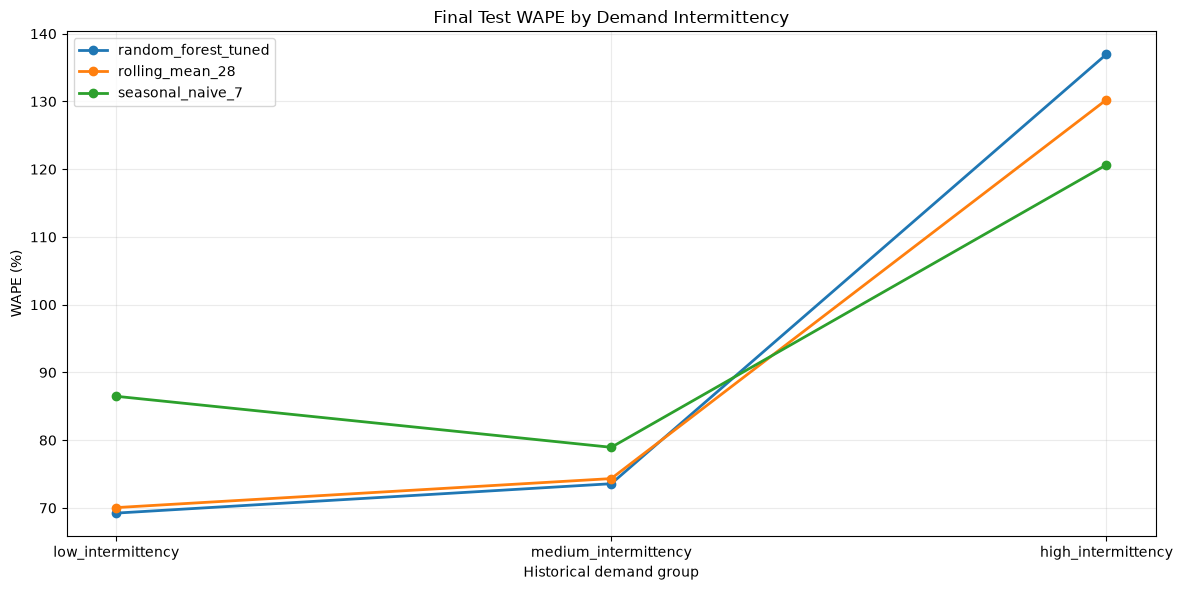

In [16]:
intermittency_plot_data = (
    demand_group_metrics.loc[
        demand_group_metrics[
            'model'
        ].isin([
            'random_forest_tuned',
            'rolling_mean_28',
            'seasonal_naive_7'
        ])
    ]
)

group_order = [
    'low_intermittency',
    'medium_intermittency',
    'high_intermittency'
]

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for model_name, group in (
    intermittency_plot_data.groupby(
        'model'
    )
):
    group = (
        group.set_index(
            'demand_group'
        )
        .reindex(group_order)
        .reset_index()
    )

    ax.plot(
        group['demand_group'],
        group['WAPE_percentage'],
        marker='o',
        linewidth=2,
        label=model_name
    )

ax.set_title(
    'Final Test WAPE by Demand Intermittency'
)

ax.set_xlabel(
    'Historical demand group'
)

ax.set_ylabel(
    'WAPE (%)'
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'intermittency_performance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [17]:
# Zero sales vs positive sales observations
evaluation_df[
    'demand_state'
] = np.where(
    evaluation_df['sales'].eq(0),
    'zero_sales',
    'positive_sales'
)

demand_state_metrics = (
    calculate_grouped_metrics(
        evaluation_df,
        [
            'model',
            'demand_state'
        ]
    )
)

demand_state_metrics[
    [
        'model',
        'demand_state',
        'observations',
        'MAE',
        'RMSE',
        'WAPE',
        'bias'
    ]
].sort_values(
    [
        'demand_state',
        'MAE'
    ]
)

,model,demand_state,observations,MAE,RMSE,WAPE,bias
12,xgboost_tuned,positive_sales,1413,1.830425,3.637873,0.513682,-1.098033
0,linear_regression,positive_sales,1413,1.832458,3.622526,0.514253,-0.619069
6,ridge_regression,positive_sales,1413,1.832752,3.619872,0.514335,-0.614501
4,random_forest_tuned,positive_sales,1413,1.833250,3.664049,0.514475,-1.176308
8,rolling_mean_28,positive_sales,1413,1.900908,3.749371,0.533462,-1.155722
10,seasonal_naive_7,positive_sales,1413,2.366596,4.435111,0.664151,-1.272470
2,previous_day,positive_sales,1413,2.394197,4.261698,0.671897,-0.445152
11,seasonal_naive_7,zero_sales,1611,0.644941,1.835744,NaN,0.644941
9,rolling_mean_28,zero_sales,1611,0.727362,1.217449,NaN,0.727362
5,random_forest_tuned,zero_sales,1611,0.782206,1.253113,NaN,0.782206


In [18]:
# Calculating the average dorecast on zero-sales dates
zero_sales_analysis = (
    evaluation_df.loc[
        evaluation_df['sales'].eq(0)
    ]
    .groupby(
        'model',
        observed=True
    )
    .agg(
        zero_sales_observations=(
            'sales',
            'size'
        ),
        average_forecast=(
            'forecast',
            'mean'
        ),
        median_forecast=(
            'forecast',
            'median'
        ),
        maximum_forecast=(
            'forecast',
            'max'
        )
    )
    .sort_values(
        'average_forecast'
    )
)

zero_sales_analysis

,zero_sales_observations,average_forecast,median_forecast,maximum_forecast
model,,,,
seasonal_naive_7,1611,0.644941,0.000000,37.000000
rolling_mean_28,1611,0.727362,0.464286,13.824942
random_forest_tuned,1611,0.782206,0.592997,13.078042
xgboost_tuned,1611,0.857898,0.563796,11.106527
previous_day,1611,0.897579,0.000000,22.000000
linear_regression,1611,0.938397,0.588993,17.306455
ridge_regression,1611,0.946937,0.606475,17.291290


In [19]:
# Item level performances
item_metrics = (
    calculate_grouped_metrics(
        evaluation_df,
        [
            'model',
            'item_id',
            'cat_id',
            'demand_group'
        ]
    )
)

item_metrics[
    'WAPE_percentage'
] = (
    item_metrics['WAPE']
    * 100
)

random_forest_item_metrics = (
    item_metrics.loc[
        item_metrics['model']
        == 'random_forest_tuned'
    ]
    .sort_values('WAPE')
)

random_forest_item_metrics.head(10)

,model,item_id,cat_id,demand_group,observations,total_actual_sales,total_forecast_sales,MAE,RMSE,WAPE,bias,WAPE_percentage
242,random_forest_tuned,FOODS_3_511,FOODS,medium_intermittency,28,715.0,553.852130,6.659315,9.570620,0.260784,-5.755281,26.078438
230,random_forest_tuned,FOODS_3_037,FOODS,low_intermittency,28,197.0,162.332861,3.288925,4.399405,0.467461,-1.238112,46.746147
240,random_forest_tuned,FOODS_3_499,FOODS,low_intermittency,28,357.0,417.380748,6.025712,7.997473,0.472605,2.156455,47.260489
243,random_forest_tuned,FOODS_3_561,FOODS,low_intermittency,28,135.0,111.561607,2.429670,2.964674,0.503931,-0.837085,50.393146
301,random_forest_tuned,HOUSEHOLD_1_339,HOUSEHOLD,low_intermittency,28,149.0,129.215399,2.745241,3.396908,0.515884,-0.706593,51.588416
251,random_forest_tuned,FOODS_3_822,FOODS,low_intermittency,28,78.0,90.420630,1.469624,1.770506,0.527557,0.443594,52.755735
274,random_forest_tuned,HOBBIES_1_295,HOBBIES,low_intermittency,28,221.0,187.136086,4.368267,5.692685,0.553446,-1.209426,55.344559
224,random_forest_tuned,FOODS_2_307,FOODS,low_intermittency,28,82.0,50.448697,1.678560,2.073908,0.573167,-1.126832,57.316684
236,random_forest_tuned,FOODS_3_231,FOODS,low_intermittency,28,129.0,75.249084,2.648645,3.281916,0.574900,-1.919676,57.489967
263,random_forest_tuned,HOBBIES_1_164,HOBBIES,low_intermittency,28,42.0,27.814827,0.865852,1.141294,0.577235,-0.506613,57.723499


In [20]:
# Inspect the most difficult products 
random_forest_item_metrics.tail(10)

,model,item_id,cat_id,demand_group,observations,total_actual_sales,total_forecast_sales,MAE,RMSE,WAPE,bias,WAPE_percentage
216,random_forest_tuned,FOODS_1_010,FOODS,high_intermittency,28,6.0,8.595658,0.438414,0.576192,2.045932,0.092702,204.593213
221,random_forest_tuned,FOODS_2_280,FOODS,high_intermittency,28,9.0,24.444547,0.784451,0.842304,2.440515,0.551591,244.051464
264,random_forest_tuned,HOBBIES_1_170,HOBBIES,high_intermittency,28,4.0,9.230421,0.395580,0.469056,2.769057,0.186801,276.905741
267,random_forest_tuned,HOBBIES_1_202,HOBBIES,medium_intermittency,28,10.0,28.807238,1.061707,1.196355,2.972781,0.671687,297.278064
273,random_forest_tuned,HOBBIES_1_294,HOBBIES,high_intermittency,28,3.0,8.040291,0.333687,0.360308,3.114414,0.180010,311.441354
237,random_forest_tuned,FOODS_3_264,FOODS,medium_intermittency,28,6.0,23.329068,0.809913,0.841584,3.779595,0.618895,377.959518
321,random_forest_tuned,HOUSEHOLD_2_458,HOUSEHOLD,high_intermittency,28,1.0,5.353879,0.212730,0.242516,5.956443,0.155496,595.644269
298,random_forest_tuned,HOUSEHOLD_1_277,HOUSEHOLD,low_intermittency,28,3.0,38.380596,1.266315,1.335525,11.818942,1.263593,1181.894173
276,random_forest_tuned,HOBBIES_1_302,HOBBIES,high_intermittency,28,0.0,4.089282,0.146046,0.151157,NaN,0.146046,NaN
283,random_forest_tuned,HOBBIES_2_012,HOBBIES,high_intermittency,28,0.0,5.182363,0.185084,0.189389,NaN,0.185084,NaN


In [21]:
# Comparing RF and rolling mean by item
item_wape_comparison = (
    item_metrics.loc[
        item_metrics[
            'model'
        ].isin([
            'random_forest_tuned',
            'rolling_mean_28'
        ])
    ]
    .pivot(
        index='item_id',
        columns='model',
        values='WAPE'
    )
    .dropna()
)

item_wape_comparison[
    'better_model'
] = np.where(
    item_wape_comparison[
        'random_forest_tuned'
    ]
    < item_wape_comparison[
        'rolling_mean_28'
    ],
    'random_forest_tuned',
    'rolling_mean_28'
)

item_wape_comparison[
    'better_model'
].value_counts()

better_model
rolling_mean_28        54
random_forest_tuned    52
Name: count, dtype: int64

### Aggregating daily forecast plot

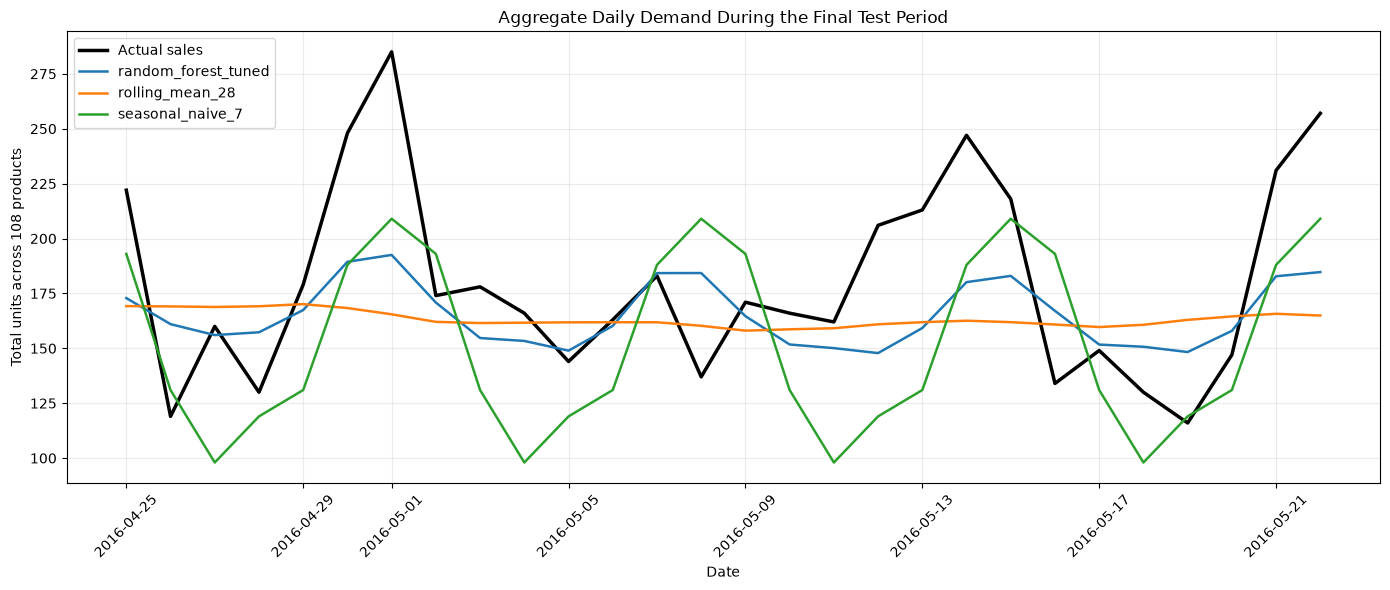

In [22]:
models_to_plot = [
    'random_forest_tuned',
    'rolling_mean_28',
    'seasonal_naive_7'
]

daily_actual = (
    test_predictions.loc[
        test_predictions['model']
        == 'random_forest_tuned'
    ]
    .groupby('date')['sales']
    .sum()
)

daily_forecasts = (
    test_predictions.loc[
        test_predictions[
            'model'
        ].isin(models_to_plot)
    ]
    .groupby(
        ['date', 'model']
    )['forecast']
    .sum()
    .unstack('model')
)

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    daily_actual.index,
    daily_actual.values,
    color='black',
    linewidth=2.5,
    label='Actual sales'
)

for model_name in models_to_plot:
    ax.plot(
        daily_forecasts.index,
        daily_forecasts[
            model_name
        ],
        linewidth=1.8,
        label=model_name
    )

ax.set_title(
    'Aggregate Daily Demand During the Final Test Period'
)

ax.set_xlabel(
    'Date'
)

ax.set_ylabel(
    'Total units across 108 products'
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'aggregate_daily_forecasts.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [23]:
# Choosing representative products objectively
representative_items = []

for demand_group, group in (
    random_forest_item_metrics.groupby(
        'demand_group',
        observed=True
    )
):
    valid_group = group.dropna(
        subset=['WAPE']
    )

    median_wape = (
        valid_group['WAPE'].median()
    )

    representative_index = (
        valid_group['WAPE']
        .sub(median_wape)
        .abs()
        .idxmin()
    )

    representative_items.append({
        'demand_group': demand_group,
        'item_id': valid_group.loc[
            representative_index,
            'item_id'
        ],
        'WAPE': valid_group.loc[
            representative_index,
            'WAPE'
        ]
    })

representative_items = pd.DataFrame(
    representative_items
)

representative_items

,demand_group,item_id,WAPE
0,high_intermittency,HOUSEHOLD_2_514,1.407730
1,low_intermittency,HOUSEHOLD_1_185,0.684292
2,medium_intermittency,FOODS_3_204,1.203477


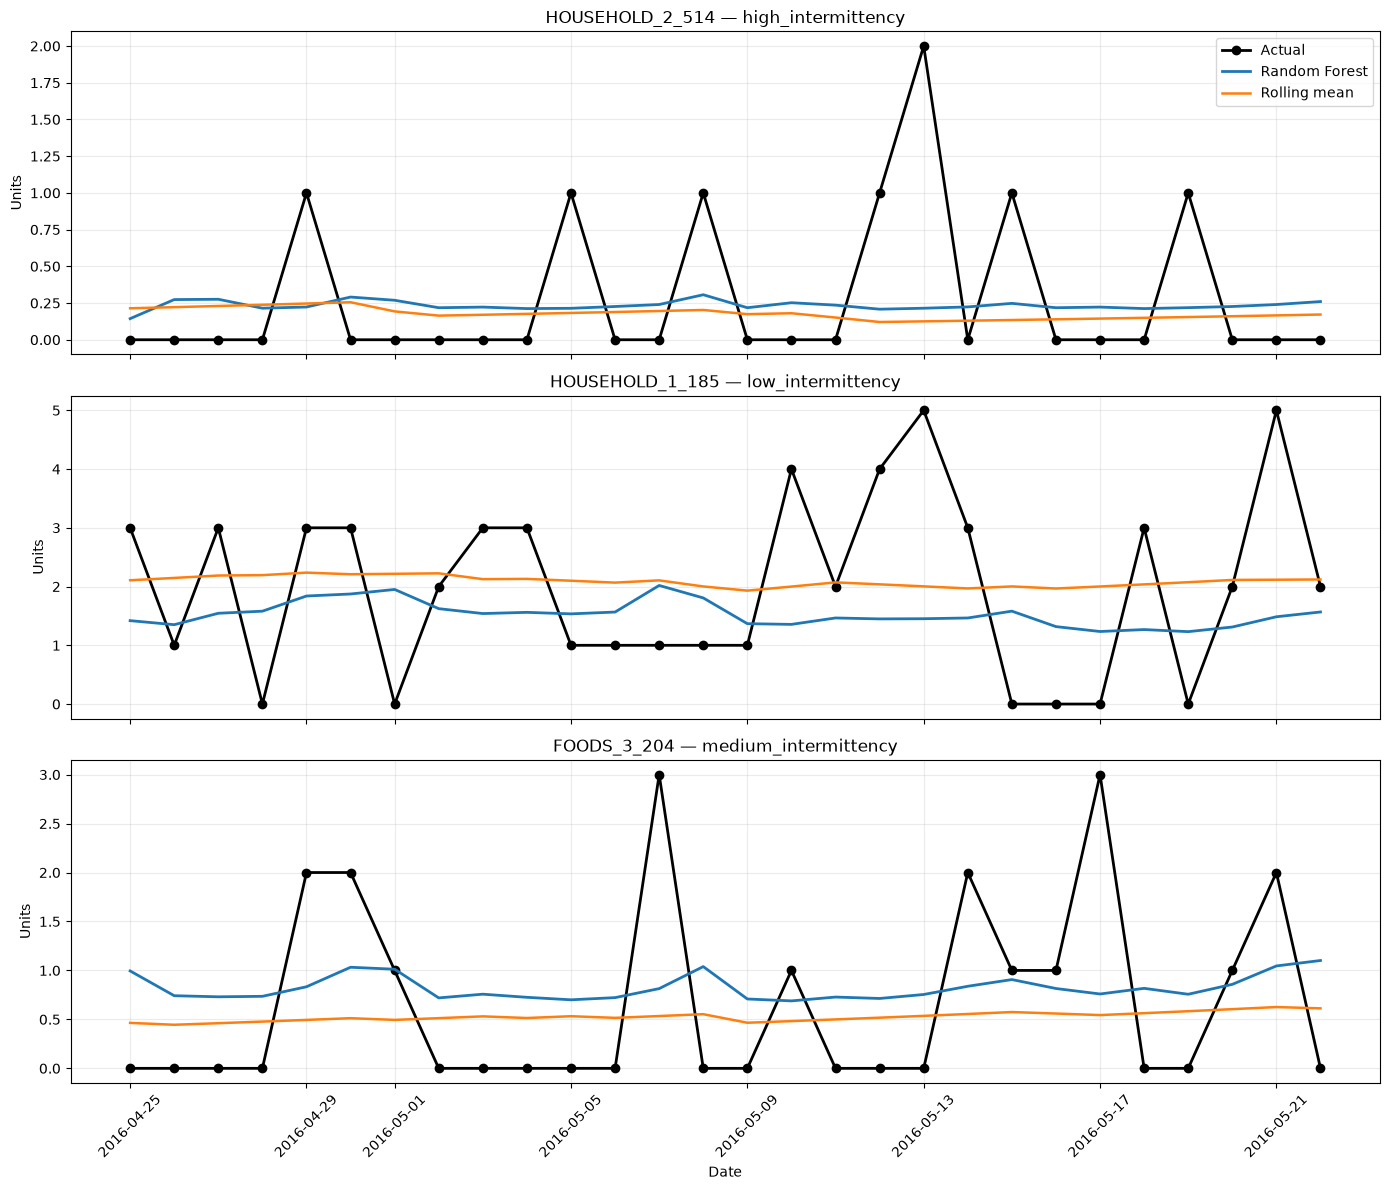

In [24]:
# Plotting
fig, axes = plt.subplots(
    nrows=len(representative_items),
    ncols=1,
    figsize=(14, 12),
    sharex=True
)

for ax, item_row in zip(
    axes,
    representative_items.itertuples(
        index=False
    )
):
    item_id = item_row.item_id

    actual_data = (
        evaluation_df.loc[
            (
                evaluation_df['item_id']
                == item_id
            )
            & (
                evaluation_df['model']
                == 'random_forest_tuned'
            )
        ]
        .sort_values('date')
    )

    rf_data = actual_data

    rolling_data = (
        evaluation_df.loc[
            (
                evaluation_df['item_id']
                == item_id
            )
            & (
                evaluation_df['model']
                == 'rolling_mean_28'
            )
        ]
        .sort_values('date')
    )

    ax.plot(
        actual_data['date'],
        actual_data['sales'],
        color='black',
        marker='o',
        linewidth=2,
        label='Actual'
    )

    ax.plot(
        rf_data['date'],
        rf_data['forecast'],
        linewidth=2,
        label='Random Forest'
    )

    ax.plot(
        rolling_data['date'],
        rolling_data['forecast'],
        linewidth=1.8,
        label='Rolling mean'
    )

    ax.set_title(
        f'{item_id} — '
        f'{item_row.demand_group}'
    )

    ax.set_ylabel(
        'Units'
    )

    ax.grid(
        alpha=0.25
    )

axes[0].legend()

axes[-1].set_xlabel(
    'Date'
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'representative_item_forecasts.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [25]:
# Saving
overall_metrics.to_csv(
    reports_directory
    / 'detailed_overall_metrics.csv',
    index=False
)

category_metrics.to_csv(
    reports_directory
    / 'category_test_metrics.csv',
    index=False
)

demand_group_metrics.to_csv(
    reports_directory
    / 'intermittency_test_metrics.csv',
    index=False
)

demand_state_metrics.to_csv(
    reports_directory
    / 'demand_state_test_metrics.csv',
    index=False
)

zero_sales_analysis.to_csv(
    reports_directory
    / 'zero_sales_analysis.csv'
)

item_metrics.to_csv(
    reports_directory
    / 'item_test_metrics.csv',
    index=False
)

item_profiles.to_csv(
    reports_directory
    / 'item_demand_profiles.csv',
    index=False
)

representative_items.to_csv(
    reports_directory
    / 'representative_items.csv',
    index=False
)

print('Detailed evaluation results saved.')

Detailed evaluation results saved.
